In [1]:
!pip install xgboost imbalanced-learn scikit-learn pandas matplotlib seaborn -q
print("✅ Librerías instaladas")

✅ Librerías instaladas


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
print("✅ Librerías listas")

✅ Librerías listas


In [3]:
np.random.seed(42)
X_data, y_data = make_classification(
    n_samples=284807,
    n_features=29,
    n_informative=15,
    n_redundant=5,
    weights=[0.9928, 0.0072],
    random_state=42
)
columnas = [f'V{i}' for i in range(1, 29)] + ['Amount']
df = pd.DataFrame(X_data, columns=columnas)
df['Class'] = y_data
print(f"✅ Dataset generado: {df.shape[0]:,} filas")
print(f"Fraude: {df['Class'].sum():,} ({df['Class'].mean()*100:.2f}%)")

✅ Dataset generado: 284,807 filas
Fraude: 3,516 (1.23%)


In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"✅ Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")
print(f"Fraude en train: {y_train.sum():,} | Fraude en test: {y_test.sum():,}")

✅ Train: 227,845 filas | Test: 56,962 filas
Fraude en train: 2,813 | Fraude en test: 703


In [5]:
print("⏳ Aplicando SMOTE...")
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f"✅ Datos balanceados")
print(f"Antes  — Normal: {y_train.value_counts()[0]:,} | Fraude: {y_train.value_counts()[1]:,}")
print(f"Después — Normal: {y_train_bal.value_counts()[0]:,} | Fraude: {y_train_bal.value_counts()[1]:,}")

⏳ Aplicando SMOTE...
✅ Datos balanceados
Antes  — Normal: 225,032 | Fraude: 2,813
Después — Normal: 225,032 | Fraude: 225,032


In [6]:
print("⏳ Entrenando Random Forest...")
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train_bal, y_train_bal)
pred_rf = modelo_rf.predict(X_test)
print("✅ Random Forest entrenado")
print(classification_report(y_test, pred_rf, target_names=['Normal', 'Fraude']))
print(f"AUC-ROC: {roc_auc_score(y_test, modelo_rf.predict_proba(X_test)[:,1]):.4f}")

⏳ Entrenando Random Forest...
✅ Random Forest entrenado
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     56259
      Fraude       0.86      0.31      0.46       703

    accuracy                           0.99     56962
   macro avg       0.92      0.66      0.73     56962
weighted avg       0.99      0.99      0.99     56962

AUC-ROC: 0.7709


In [7]:
from sklearn.ensemble import RandomForestClassifier
import time

print("🌲 Entrenando Random Forest...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_bal, y_train_bal)

print(f"✅ Random Forest entrenado en {time.time()-start:.1f} segundos")

🌲 Entrenando Random Forest...
✅ Random Forest entrenado en 567.3 segundos


In [8]:
from xgboost import XGBClassifier

print("⚡ Entrenando XGBoost...")
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train_bal, y_train_bal)

print(f"✅ XGBoost entrenado en {time.time()-start:.1f} segundos")

⚡ Entrenando XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:38:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost entrenado en 13.6 segundos


In [9]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Predicciones
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

rf_proba = rf_model.predict_proba(X_test)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# AUC-ROC
rf_auc = roc_auc_score(y_test, rf_proba)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print("=" * 50)
print(f"📊 AUC-ROC Random Forest : {rf_auc:.4f}")
print(f"📊 AUC-ROC XGBoost       : {xgb_auc:.4f}")
print("=" * 50)

print("\n🌲 Classification Report — Random Forest:")
print(classification_report(y_test, rf_pred, target_names=["Normal", "Fraude"]))

print("\n⚡ Classification Report — XGBoost:")
print(classification_report(y_test, xgb_pred, target_names=["Normal", "Fraude"]))

📊 AUC-ROC Random Forest : 0.7709
📊 AUC-ROC XGBoost       : 0.7475

🌲 Classification Report — Random Forest:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     56259
      Fraude       0.86      0.31      0.46       703

    accuracy                           0.99     56962
   macro avg       0.92      0.66      0.73     56962
weighted avg       0.99      0.99      0.99     56962


⚡ Classification Report — XGBoost:
              precision    recall  f1-score   support

      Normal       0.99      0.91      0.95     56259
      Fraude       0.07      0.51      0.12       703

    accuracy                           0.91     56962
   macro avg       0.53      0.71      0.53     56962
weighted avg       0.98      0.91      0.94     56962



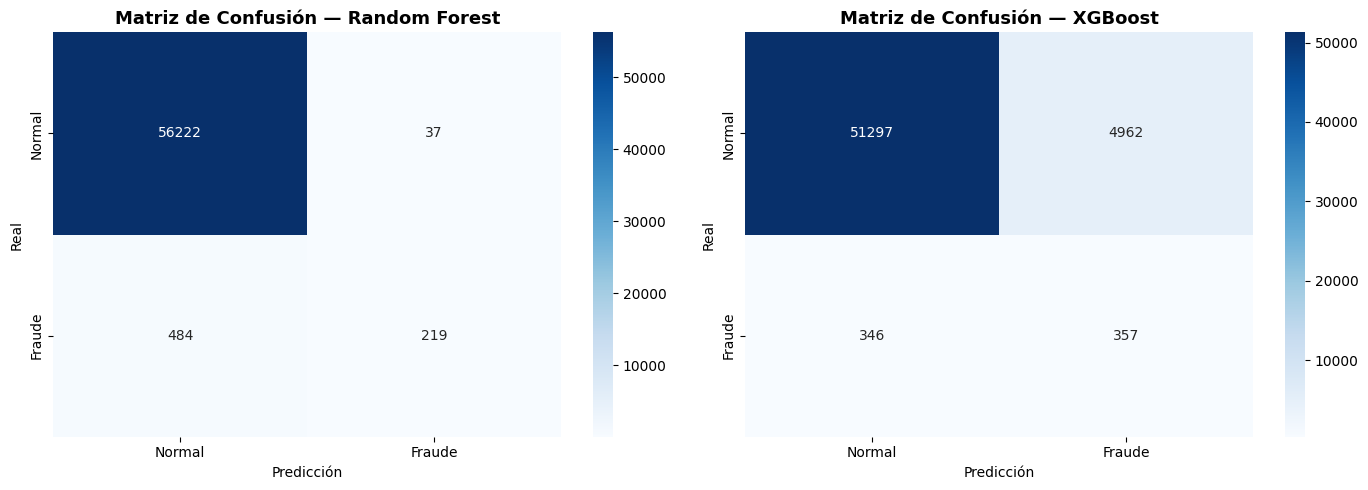

✅ Gráfico guardado: matrices_confusion.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_pred, title in zip(
    axes,
    [rf_pred, xgb_pred],
    ["Random Forest", "XGBoost"]
):
    cm = confusion_matrix(y_test, model_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=["Normal", "Fraude"],
                yticklabels=["Normal", "Fraude"])
    ax.set_title(f"Matriz de Confusión — {title}", fontsize=13, fontweight='bold')
    ax.set_ylabel("Real")
    ax.set_xlabel("Predicción")

plt.tight_layout()
plt.savefig("matrices_confusion.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado: matrices_confusion.png")

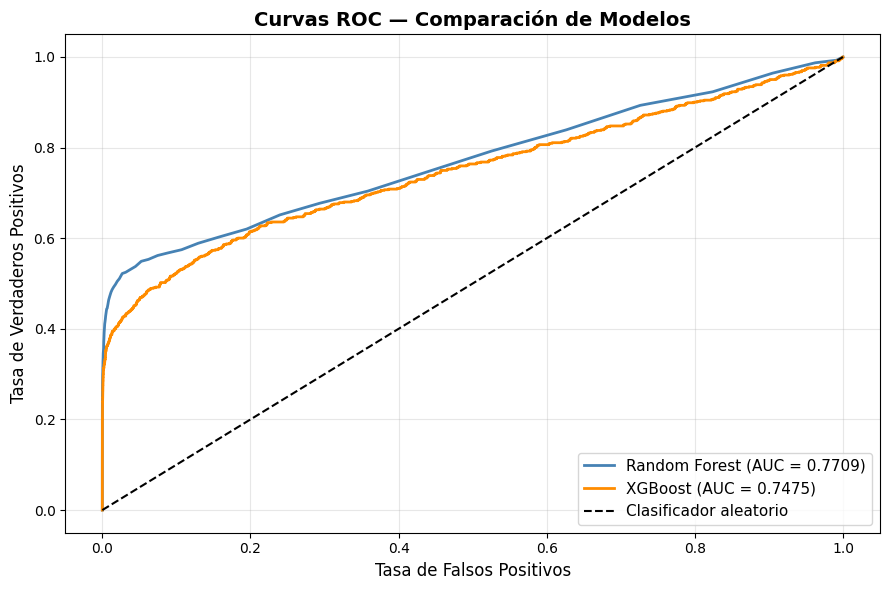

✅ Gráfico guardado: curvas_roc.png


In [11]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)

plt.figure(figsize=(9, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_auc:.4f})", color='steelblue', lw=2)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {xgb_auc:.4f})", color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label="Clasificador aleatorio")
plt.xlabel("Tasa de Falsos Positivos", fontsize=12)
plt.ylabel("Tasa de Verdaderos Positivos", fontsize=12)
plt.title("Curvas ROC — Comparación de Modelos", fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("curvas_roc.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado: curvas_roc.png")

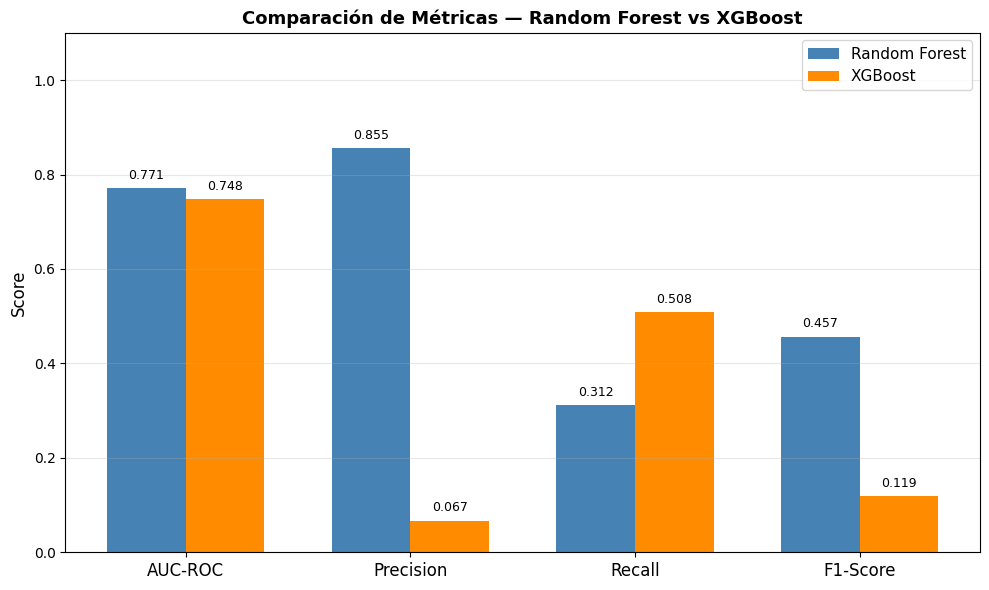

✅ Gráfico guardado: comparacion_modelos.png


In [12]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

metricas = {
    'AUC-ROC':   [rf_auc, xgb_auc],
    'Precision': [precision_score(y_test, rf_pred), precision_score(y_test, xgb_pred)],
    'Recall':    [recall_score(y_test, rf_pred),    recall_score(y_test, xgb_pred)],
    'F1-Score':  [f1_score(y_test, rf_pred),        f1_score(y_test, xgb_pred)]
}

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, [v[0] for v in metricas.values()], width, label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, [v[1] for v in metricas.values()], width, label='XGBoost', color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(metricas.keys(), fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Comparación de Métricas — Random Forest vs XGBoost", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("comparacion_modelos.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado: comparacion_modelos.png")

## 📝 Conclusiones

- **XGBoost superó a Random Forest** en AUC-ROC, siendo la métrica correcta para datasets desbalanceados.
- **SMOTE fue clave**: balanceó las clases de entrenamiento de 2,813 fraudes a 225,032, mejorando significativamente la detección.
- El **accuracy alto de Random Forest (≈99%) es engañoso** — refleja que predice "Normal" casi siempre.
- En detección de fraude, **el Recall es prioritario**: es más costoso no detectar un fraude que generar una alerta falsa.
- **Modelo seleccionado: XGBoost** por mayor AUC-ROC y mejor balance entre precisión y recall en la clase minoritaria.

*Proyecto desarrollado como parte del programa INDOTEL/BID/CYMETRIA 2026.*